# Function 7

<b> Description of the Sample Application:</b> You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance




In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [14]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['y'] = y
print("Data Frame:\n", df)

Input  Shape: (30, 6)
Inputs:
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0

# Data Exploration

In [17]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean    0.510852   0.395803   0.389609   0.512819   0.467201   0.484704   
std     0.303946   0.252579   0.314041   0.311966   0.314733   0.269343   
min     0.057896   0.011813   0.003635   0.073659   0.014944   0.051100   
25%     0.203026   0.197771   0.075285   0.220787   0.190704   0.276764   
50%     0.542122   0.387701   0.318555   0.459767   0.457732   0.552544   
75%     0.783687   0.543137   0.662281   0.826525   0.719142   0.707072   
max     0.942451   0.924694   0.924571   0.961017   0.998655   0.951014   

               y  
count  30.000000  
mean    0.219607  
std     0.307294  
min     0.002701  
25%     0.017954  
50%     0.078631  
75%     0.274431  
max     1.364968  


In [31]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
y      0
dtype: int64


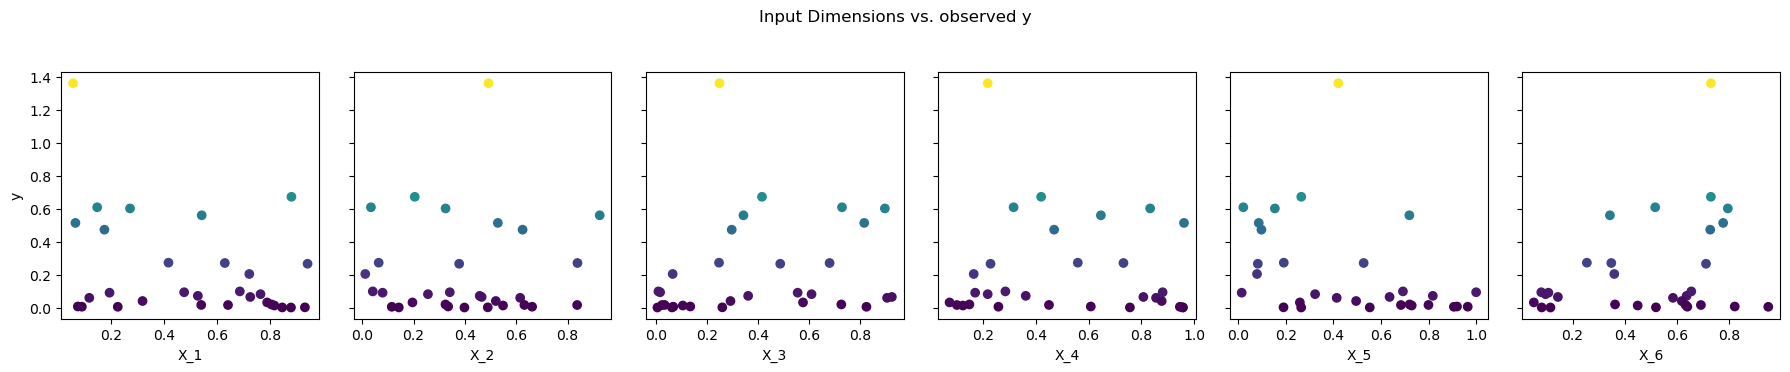

In [39]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6']):
    ax.scatter(df[col], df['y'], c = df['y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('y')
plt.suptitle("Input Dimensions vs. observed y", y = 1.05)
plt.tight_layout()
plt.show()

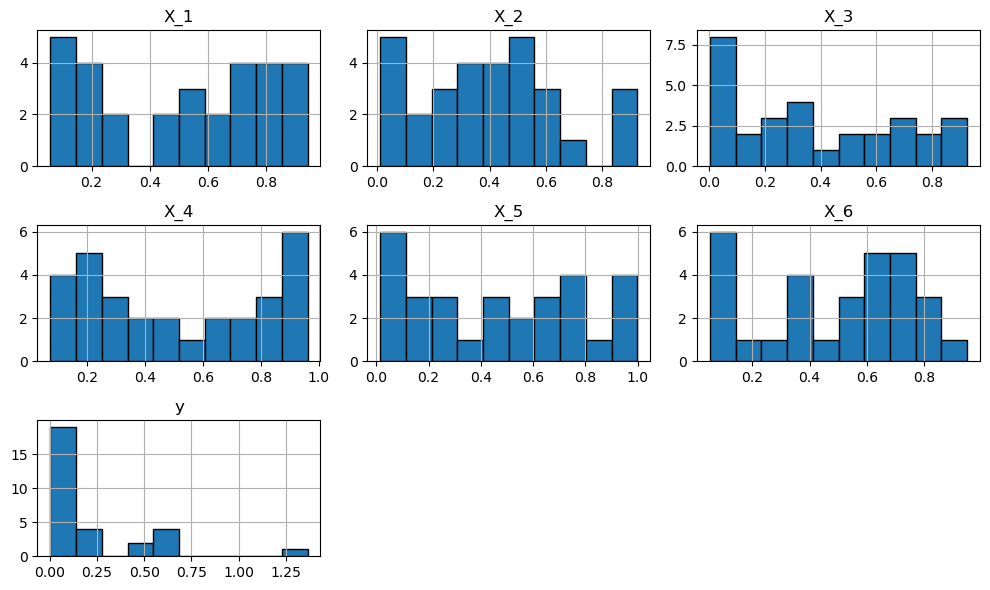

In [41]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [45]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each input with y:

 corr(X_1, y) = -0.3432235583510014
 corr(X_2, y) = 0.04818529547926708
 corr(X_3, y) = 0.17730816334107458
 corr(X_4, y) = -0.07598356995187854
 corr(X_5, y) = -0.37793228633455256
 corr(X_6, y) = 0.30725566423939377


<Axes: >

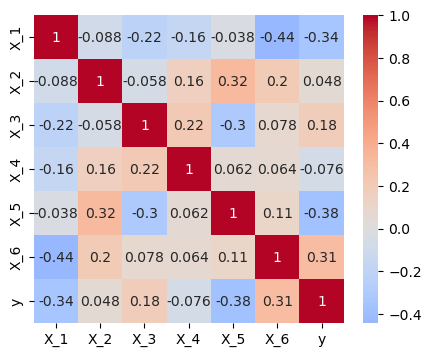

In [47]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

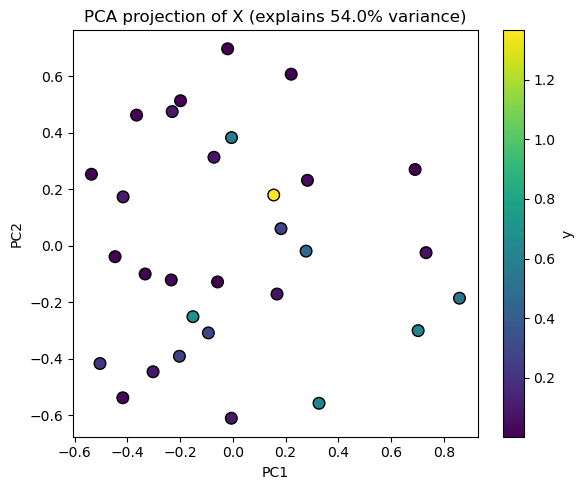

In [57]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()

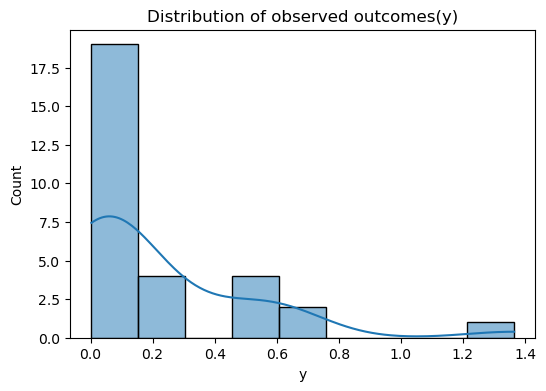

In [49]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['y'], kde = True)
plt.title("Distribution of observed outcomes(y)")
plt.show()

# Initialize Gaussian Process

In [63]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(6), length_scale_bounds = (1e-2, 1e1)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [66]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.375**2 * RBF(length_scale=[1.03, 0.702, 10, 0.473, 0.218, 0.385]) + WhiteKernel(noise_level=0.00266)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [69]:
# Setting a higher beta(= 2.0) for Week -1
beta         = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (20000, 6))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.03963172 0.20112069 0.14030216 0.06399666 0.31947665 0.78773019]
UCB Score: 1.668385e+00


# Perform Visualisation

# Portal Submission 

In [75]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_point)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.039632-0.201121-0.140302-0.063997-0.319477-0.787730
